                                                   Introduction

A stroke is an acute medical condition that occurs when the cerebral blood supply is disrupted, resulting in reduced oxygen and nutrient delivery to brain tissue and subsequent neuronal damage. This disruption may be caused by an obstruction of blood flow (ischemic stroke), rupture of a blood vessel leading to intracranial bleeding (hemorrhagic stroke), or a transient interruption known as a transient ischemic attack (TIA), which presents with temporary neurological symptoms without permanent damage. Due to its rapid progression and potential for severe morbidity and mortality, early diagnosis and immediate medical intervention are critical.

In this data analysis project, we conducted an exploratory analysis to identify and visualize key risk factors associated with stroke incidence. Epidemiological evidence suggests that approximately 80% of stroke cases are preventable, emphasizing the importance of risk factor assessment and early intervention. The dataset encompasses a heterogeneous population, including variations in age, gender, lifestyle behaviors, and pre-existing medical conditions. Through the application of data visualization techniques and descriptive analytics, we aimed to detect patterns, correlations, and potential predictors of stroke occurrence. The findings of this analysis are intended to support data-driven insights for improved awareness, prevention strategies, and healthcare decision-making.


                                                 Objectives 🎯

The main objectives of this project are:
Perform exploratory data analysis (EDA) to understand data distribution and characteristics.
Identify key risk factors associated with stroke, including demographic, lifestyle, and health-related variables.
Analyze relationships and correlations between variables and their impact on stroke occurrence.
Compare stroke prevalence across different population groups (e.g., age, gender, health conditions).
Create clear and effective visualizations that communicate insights for prevention and awareness.    




                                                 Research Questions❓
1.Are there significant differences in stroke prevalence between males and females?
2.How does age influence the likelihood of experiencing a stroke?
3.To what extent are Body Mass Index (BMI) and blood glucose levels associated with an increased risk of stroke?
4.Does smoking significantly increase the risk of stroke?
5.Is heart disease a significant risk factor for stroke occurrence?
6.Is work type associated with hypertension and stroke risk?
7.Does living in an urban versus rural area affect the likelihood of experiencing a stroke?
8.Is marital status associated with higher or lower stroke risk?
9.Can high workload or work-related stress lead to high blood pressure and subsequently increase stroke risk?
10.Which variables serve as the strongest predictors of stroke?




In [138]:
# Data processing sequence initiated

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
import matplotlib.ticker as mtick



                                                 Data Preprocessing


In [139]:
#Load Dataset
df = pd.read_csv('stroke_data.csv')

In [140]:
# Remove ID column
df.drop('id', axis=1, inplace=True)

I removed the id column because it does not provide meaningful information for analysis. It is only a unique identifier for each record and does not contribute to patterns or predictions.


Dataset Overview

In [141]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   str    
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   str    
 5   work_type          5110 non-null   str    
 6   Residence_type     5110 non-null   str    
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                4909 non-null   float64
 9   smoking_status     5110 non-null   str    
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int64(3), str(5)
memory usage: 439.3 KB


In [142]:
df.shape

(5110, 11)

In [143]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [144]:
df.describe(include="all")

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
count,5110,5110.000000,5110.000000,5110.000000,5110,5110,5110,5110.000000,4909.000000,5110,5110.000000
unique,3,NaN,NaN,NaN,2,5,2,NaN,NaN,4,NaN
top,Female,NaN,NaN,NaN,Yes,Private,Urban,NaN,NaN,never smoked,NaN
freq,2994,NaN,NaN,NaN,3353,2925,2596,NaN,NaN,1892,NaN
mean,NaN,43.226614,0.097456,0.054012,NaN,NaN,NaN,106.147677,28.893237,NaN,0.048728
std,NaN,22.612647,0.296607,0.226063,NaN,NaN,NaN,45.283560,7.854067,NaN,0.215320
min,NaN,0.080000,0.000000,0.000000,NaN,NaN,NaN,55.120000,10.300000,NaN,0.000000
25%,NaN,25.000000,0.000000,0.000000,NaN,NaN,NaN,77.245000,23.500000,NaN,0.000000
50%,NaN,45.000000,0.000000,0.000000,NaN,NaN,NaN,91.885000,28.100000,NaN,0.000000
75%,NaN,61.000000,0.000000,0.000000,NaN,NaN,NaN,114.090000,33.100000,NaN,0.000000


Missing Values

In [145]:
df.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

Only the BMI feature had missing values, which were filled using the median BMI within each age group.
An age_group feature was created by binning the continuous age variable into ranges. This allows more accurate imputation, since BMI varies by age.


In [146]:
##Fill missing BMI values with median 

df['age_group'] = pd.cut(df['age'], bins=[0,30,45,60,75,120])

df['bmi'] = df['bmi'].fillna(
    df.groupby('age_group')['bmi'].transform('median')
)

In [147]:
df.isnull().sum()

gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
age_group            0
dtype: int64

In [148]:
df.describe(include="all")

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,age_group
count,5110,5110.000000,5110.000000,5110.000000,5110,5110,5110,5110.000000,5110.000000,5110,5110.000000,5110
unique,3,NaN,NaN,NaN,2,5,2,NaN,NaN,4,NaN,5
top,Female,NaN,NaN,NaN,Yes,Private,Urban,NaN,NaN,never smoked,NaN,"(0, 30]"
freq,2994,NaN,NaN,NaN,3353,2925,2596,NaN,NaN,1892,NaN,1570
mean,NaN,43.226614,0.097456,0.054012,NaN,NaN,NaN,106.147677,28.876634,NaN,0.048728,NaN
std,NaN,22.612647,0.296607,0.226063,NaN,NaN,NaN,45.283560,7.715616,NaN,0.215320,NaN
min,NaN,0.080000,0.000000,0.000000,NaN,NaN,NaN,55.120000,10.300000,NaN,0.000000,NaN
25%,NaN,25.000000,0.000000,0.000000,NaN,NaN,NaN,77.245000,23.600000,NaN,0.000000,NaN
50%,NaN,45.000000,0.000000,0.000000,NaN,NaN,NaN,91.885000,28.200000,NaN,0.000000,NaN
75%,NaN,61.000000,0.000000,0.000000,NaN,NaN,NaN,114.090000,32.800000,NaN,0.000000,NaN


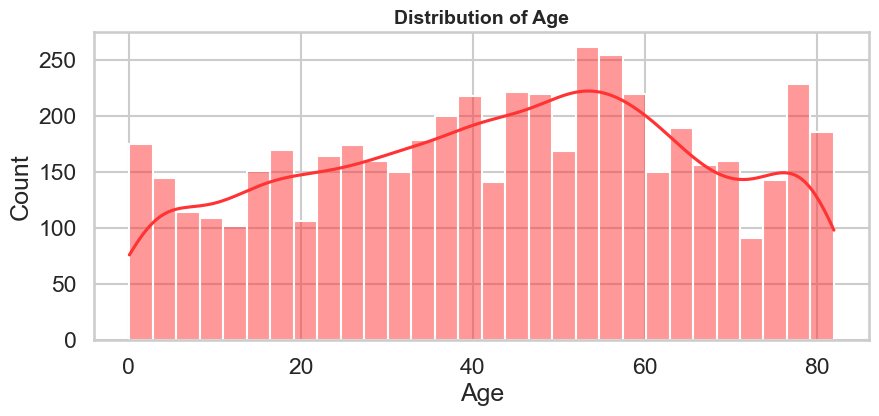

In [149]:
# Plotting the distribution of age to understand its spread and pattern in the dataset

colors = ['#FF9999','#FF6666','#FF3333','#660000','#990000']

plt.figure(figsize=(10,4))
sn.histplot(
    df['age'],
    kde=True,
    bins=30,
    color=colors[2]  
)

plt.title("Distribution of Age", fontsize=14, fontweight='bold')
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

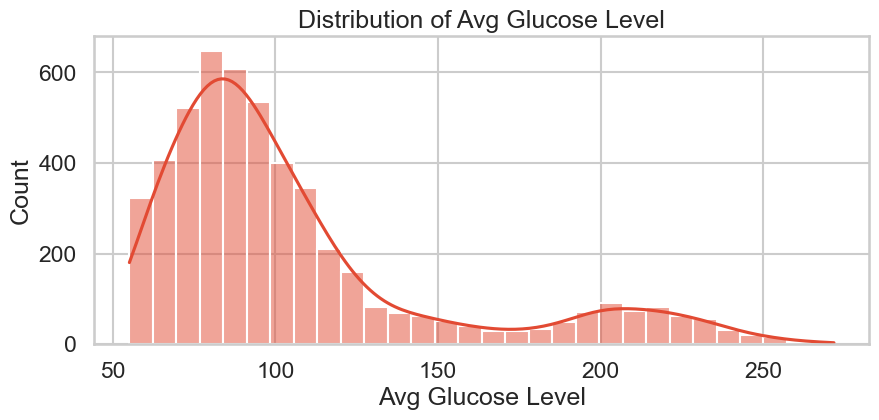

In [150]:
# Plotting the distribution of avg_glucose_level to understand its spread and pattern in the dataset

colors = ['#FF9999','#FF6666','#FF3333','#660000','#990000']
plt.figure(figsize=(10,4))
sn.histplot(df['avg_glucose_level'], kde=True, bins=30)
plt.title("Distribution of Avg Glucose Level")
plt.xlabel("Avg Glucose Level")
plt.ylabel("Count")
plt.show()

In [151]:
# Counting extreme glucose values (very low and very high) to detect potential outliers

low = df[df['avg_glucose_level'] < 23].shape[0]
high = df[df['avg_glucose_level'] > 200].shape[0]

low, high


(0, 434)

The distribution of average glucose levels is right-skewed, with no extremely low values and a notable number of high values (434 cases above 200), indicating potential outliers on the higher end.

In [152]:
# Clipping extreme glucose values to reduce the impact of outliers

df['avg_glucose_level'] = df['avg_glucose_level'].clip(lower=23, upper=200)


In [153]:
# Applying log transformation to glucose levels to reduce skewness and improve distribution

df['glucose_log'] = np.log(df['avg_glucose_level'])


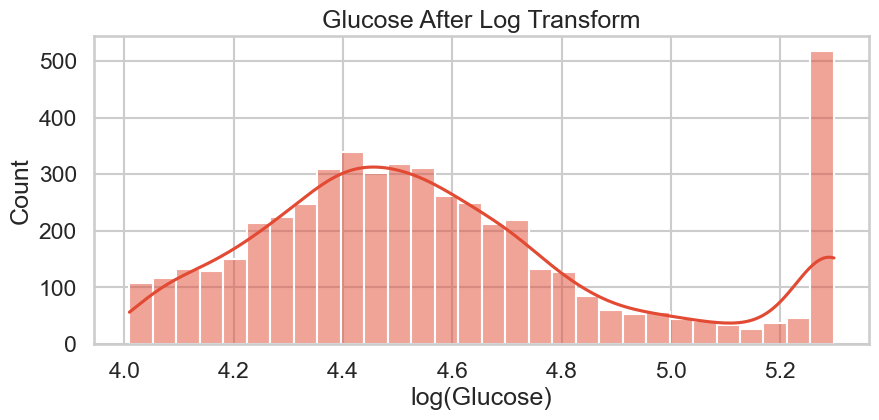

In [154]:
# Visualizing glucose distribution after log transformation to examine its shape and reduce skewness

colors = ['#FF9999','#FF6666','#FF3333','#660000','#990000']
df['glucose_log'] = np.log(df['avg_glucose_level'])
plt.figure(figsize=(10,4))
sn.histplot(df['glucose_log'], kde=True, bins=30)
plt.title("Glucose After Log Transform")
plt.xlabel("log(Glucose)")
plt.ylabel("Count")
plt.show()


A log transformation was applied to the glucose variable after clipping values to the range of 23–200 to reduce the impact of extreme values. The resulting distribution appears less right-skewed and more symmetric. The log function compresses high values, reducing variability and making the data more suitable for statistical analysis and predictive modeling.

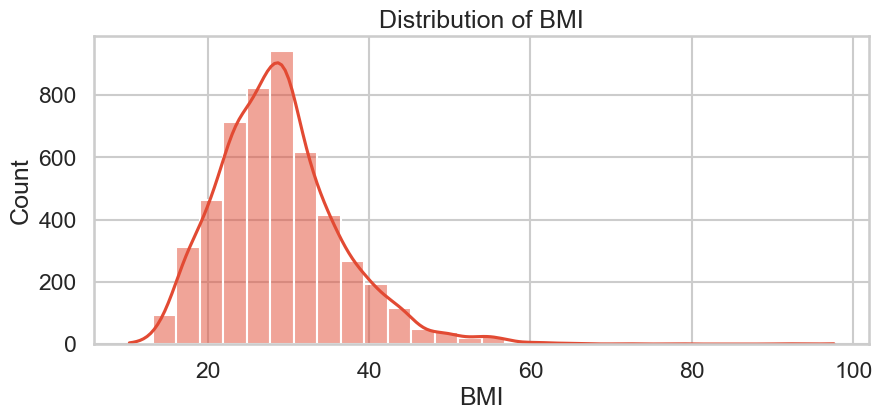

In [155]:
# Visualizing BMI distribution to understand its spread and variability in the dataset

colors = ['#FF9999','#FF6666','#FF3333','#660000','#990000']
plt.figure(figsize=(10,4))
sn.histplot(df['bmi'], kde=True, bins=30)
plt.title("Distribution of BMI")
plt.xlabel("BMI")
plt.ylabel("Count")
plt.show()



In [156]:
# Counting extreme BMI values (very low and very high) to identify potential outliers

low_bmi = df[df['bmi'] < 18].shape[0]
high_bmi = df[df['bmi'] > 46].shape[0]

low_bmi, high_bmi

(273, 129)

The graph shows the distribution of BMI values, with most observations concentrated in the mid-range and a slight right skew. There are 273 low values (below 18) and 129 high values (above 46), indicating the presence of outliers on both ends of the distribution.

In [157]:
# Replacing extreme BMI values by capping them within a defined range to handle outliers

df['bmi'] = np.where(df['bmi'] < 18, 18,
                     np.where(df['bmi'] > 46, 46,
                              df['bmi']))


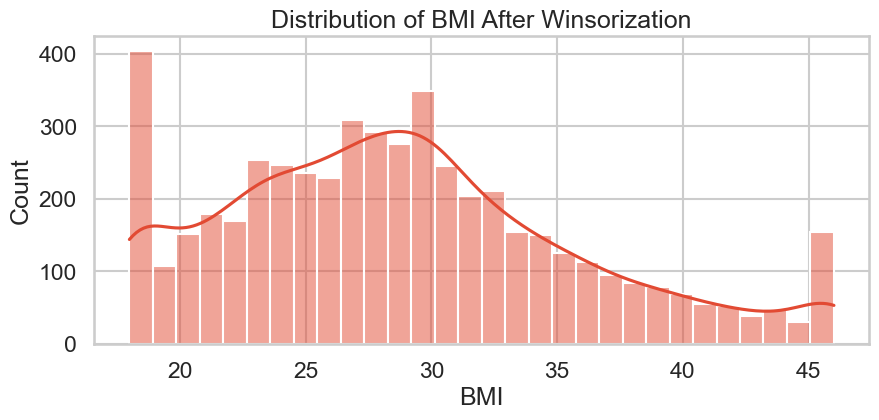

In [158]:
# Visualizing the BMI distribution after Winsorization to check the effect of outlier capping

plt.figure(figsize=(10,4))
sn.histplot(df['bmi'], kde=True, bins=30)
plt.title("Distribution of BMI After Winsorization")
plt.xlabel("BMI")
plt.ylabel("Count")
plt.show()



Winsorization was applied to BMI values by capping values below 18 at 18 and above 46 at 46, in order to reduce the impact of outliers. The resulting distribution is more stable with less influence from extreme values, improving the reliability of statistical analysis.

In [159]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,age_group,glucose_log
0,Male,67.0,0,1,Yes,Private,Urban,200.00,36.6,formerly smoked,1,"(60, 75]",5.298317
1,Female,61.0,0,0,Yes,Self-employed,Rural,200.00,29.7,never smoked,1,"(60, 75]",5.298317
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1,"(75, 120]",4.662684
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1,"(45, 60]",5.143008
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1,"(75, 120]",5.159745


Encoding Categorical Variables to Numeric (0/1) Values

Explanation
In this project, several categorical variables were converted into numeric values (0 and 1) to enable statistical analysis and predictive modeling, since most algorithms cannot process text directly.
Gender: Female → 0, Male → 1
Ever_married: No → 0, Yes → 1
Residence_type: Rural → 0, Urban → 1

This encoding allows:
Calculation of means, correlations, and other statistics on categorical data.
Use in models such as logistic regression or machine learning algorithms.
Preservation of category proportions in statistical analyses.

In [160]:
# Checking the distribution of gender categories to identify rare or inconsistent values

df['gender'].value_counts()


gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

In [161]:
# Removing the 'Other' gender category due to insufficient sample size

df = df[df['gender'] != 'Other']


The value_counts() function displays the number of occurrences for each category in the gender column (e.g., Male, Female, Other).
The second line filters the dataset by removing all rows where the gender is "Other", keeping only Male and Female. This is often done to simplify the analysis or when the "Other" category has very few observations and is not statistically representative.

In [162]:
df['gender'].value_counts()


gender
Female    2994
Male      2115
Name: count, dtype: int64

In [163]:
df.info()

<class 'pandas.DataFrame'>
Index: 5109 entries, 0 to 5109
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   gender             5109 non-null   str     
 1   age                5109 non-null   float64 
 2   hypertension       5109 non-null   int64   
 3   heart_disease      5109 non-null   int64   
 4   ever_married       5109 non-null   str     
 5   work_type          5109 non-null   str     
 6   Residence_type     5109 non-null   str     
 7   avg_glucose_level  5109 non-null   float64 
 8   bmi                5109 non-null   float64 
 9   smoking_status     5109 non-null   str     
 10  stroke             5109 non-null   int64   
 11  age_group          5109 non-null   category
 12  glucose_log        5109 non-null   float64 
dtypes: category(1), float64(4), int64(3), str(5)
memory usage: 524.0 KB


In [164]:
# Converting gender categories into binary numeric values for modeling compatibility

df['gender'] = df['gender'].apply(lambda x: 0 if x=='Female' else (1 if x=='Male' else x))

# Verifying that the encoding was applied correctly and checking for unexpected or missing values

print(df['gender'].unique())
print(df['gender'].isna().sum())

[1 0]
0


The gender variable was converted into numerical values: Female (0) and Male (1), to enable use in statistical models. Then, the unique values and the number of missing values (NaN) were checked to ensure the transformation was applied correctly.

In [165]:
# Inspecting the unique marital status categories and their frequency to detect inconsistencies or rare values

df['ever_married'].unique()
df['ever_married'].value_counts()


ever_married
Yes    3353
No     1756
Name: count, dtype: int64

In [166]:
# Encoding the 'ever_married' variable into binary values (1 = Yes, 0 = No)
# This conversion ensures compatibility with statistical models that require numeric inputs

df['ever_married'] = df['ever_married'].apply(lambda x: 1 if x=='Yes' else (0 if x=='No' else x))

# Verifying the encoding by checking unique values, distribution, and potential missing entries

print(df['ever_married'].unique())
print(df['ever_married'].value_counts())
print(df['ever_married'].isna().sum())

[1 0]
ever_married
1    3353
0    1756
Name: count, dtype: int64
0


The unique values and their distribution in the marital status column were examined. Then, the variable was converted into numeric form: "Yes" as 1 and "No" as 0, to enable statistical analysis and modeling. Finally, the distribution and the number of missing values (NaN) were checked to ensure the transformation was applied correctly.

In [167]:
# Examining the distribution of residence types to confirm category consistency

df['Residence_type'].value_counts()


Residence_type
Urban    2596
Rural    2513
Name: count, dtype: int64

In [168]:
# Encoding residence type into binary values (1 = Urban, 0 = Rural)
# This transformation ensures compatibility with statistical and machine learning models

df['Residence_type'] = df['Residence_type'].apply(lambda x: 1 if x=='Urban' else (0 if x=='Rural' else x))

# Validating the encoding by checking unique values, category counts, and potential missing entries

print(df['Residence_type'].unique())
print(df['Residence_type'].value_counts())
print(df['Residence_type'].isna().sum())

[1 0]
Residence_type
1    2596
0    2513
Name: count, dtype: int64
0


The distribution of residence type (Urban/Rural) was examined. The variable was then converted into numeric form: "Urban" as 1 and "Rural" as 0, enabling statistical analysis and modeling. Finally, the distribution and number of missing values (NaN) were checked to ensure the transformation was correct.

In [169]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,age_group,glucose_log
0,1,67.0,0,1,1,Private,1,200.00,36.6,formerly smoked,1,"(60, 75]",5.298317
1,0,61.0,0,0,1,Self-employed,0,200.00,29.7,never smoked,1,"(60, 75]",5.298317
2,1,80.0,0,1,1,Private,0,105.92,32.5,never smoked,1,"(75, 120]",4.662684
3,0,49.0,0,0,1,Private,1,171.23,34.4,smokes,1,"(45, 60]",5.143008
4,0,79.0,1,0,1,Self-employed,0,174.12,24.0,never smoked,1,"(75, 120]",5.159745


                                                 Initial Insights About Dataset
The dataset contains key demographic, lifestyle, and clinical variables relevant to stroke analysis. After preprocessing, it becomes evident that stroke cases represent only a small fraction of the sample, indicating class imbalance. Additionally, several variables show noticeable differences between individuals with and without stroke, suggesting potential associations that warrant deeper exploration in the subsequent analysis.

 Univariate analysis of categorical variables


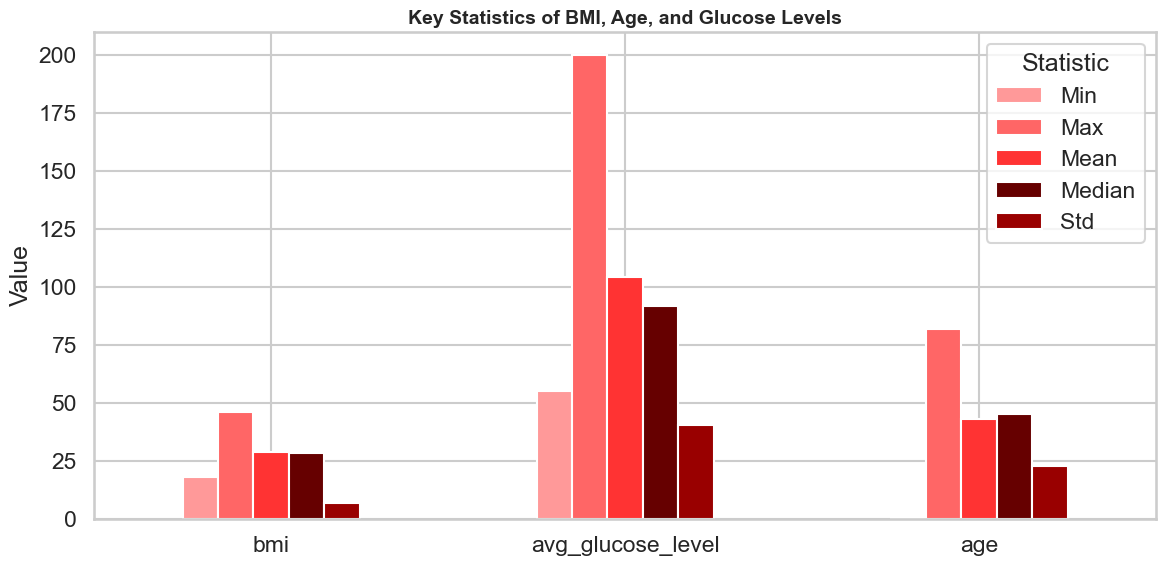

In [170]:
# Computing key descriptive statistics (Min, Max, Mean, Median, Std) to compare the central tendency 
# and variability of BMI, glucose levels, and age. This helps identify differences in scale, spread, 
# and potential outliers before deeper analysis.

num_cols = ['bmi', 'avg_glucose_level', 'age']
stats_full = pd.DataFrame({
    'Min': df[num_cols].min(),
    'Max': df[num_cols].max(),
    'Mean': df[num_cols].mean(),
    'Median': df[num_cols].median(),
    'Std': df[num_cols].std()
}).round(2)

colors = ['#FF9999','#FF6666','#FF3333','#660000','#990000'] 

# Visualizing the summary statistics as a grouped bar chart to highlight contrasts between variables 
# and provide a quick overview of their distribution characteristics.

ax = stats_full.plot(kind='bar', figsize=(12,6), color=colors)
plt.title("Key Statistics of BMI, Age, and Glucose Levels", fontsize=14, fontweight='bold')
plt.ylabel("Value")
plt.xticks(rotation=0)
plt.legend(title='Statistic')
plt.tight_layout()
plt.show()


The chart presents key statistical measures for the numeric variables: BMI, Age, and Average Glucose Level.
Each group of bars represents one variable.
Each colored bar shows a different measure: Minimum, Maximum, Mean, Median, and Standard Deviation.
This visualization allows a clear comparison of the variables’ central tendency, spread, and extremes.
It helps quickly identify which variables have higher variability or extreme values.

The following section presents a comprehensive analysis of the dataset using visualizations, with the aim of answering the research questions and uncovering significant trends and relationships related

1.Are there significant differences in stroke prevalence between males and females?


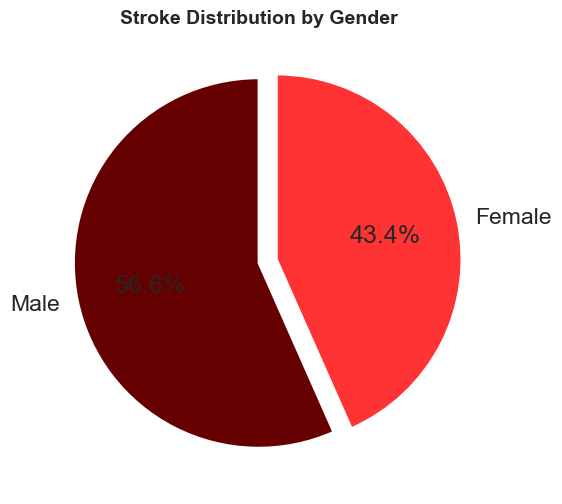

In [171]:
# Creating a pie chart to visualize the proportion of stroke cases by gender.
# This helps identify whether males or females are disproportionately represented among stroke patients.

stroke_gender = df[df['stroke']==1]['gender'].value_counts()

colors = ['#660000', '#FF3333']  
labels = ['Male', 'Female']

plt.figure(figsize=(6,6))
plt.pie(
    stroke_gender,
    labels=labels,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    explode=(0,0.1)  
)
plt.title("Stroke Distribution by Gender", fontsize=14, fontweight='bold')
plt.show()

The pie chart shows the distribution of stroke cases by gender. Each slice represents the proportion of males and females who experienced a stroke.

2.How does age influence the likelihood of experiencing a stroke?


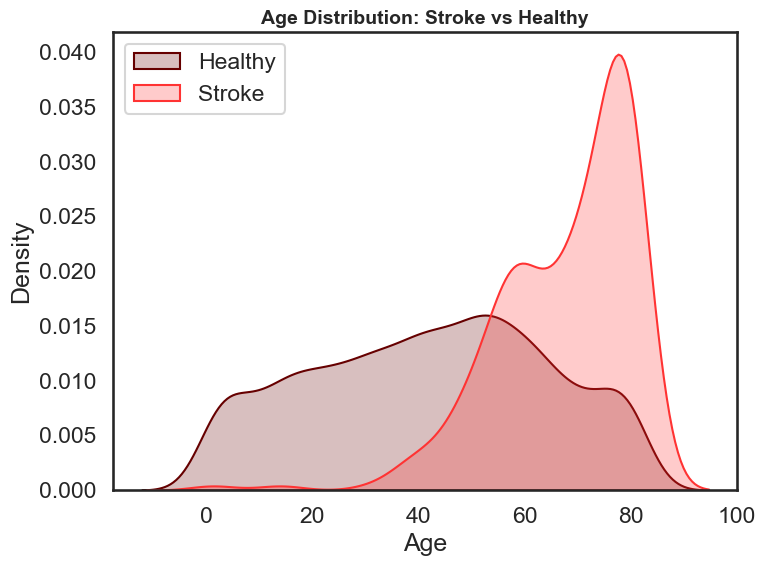

In [181]:
# Using KDE plots to compare the age distribution of stroke vs non-stroke individuals.
# This visualization highlights differences in density and helps identify whether age separates the two groups,
# revealing potential patterns or risk trends across the lifespan.

colors = ['#FF9999','#FF6666','#FF3333','#660000','#990000']

sn.set_style("white")
plt.figure(figsize=(8,6))

sn.kdeplot(
    data=df[df['stroke']==0],
    x='age',
    label='Healthy',
    color=colors[3],  
    fill=True
)
sn.kdeplot(
    data=df[df['stroke']==1],
    x='age',
    label='Stroke',
    color=colors[2], 
    fill=True
)

plt.title("Age Distribution: Stroke vs Healthy", fontsize=14, fontweight='bold')
plt.xlabel("Age")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()


The stroke group is right-skewed toward older ages, indicating a higher density among elderly individuals.
There is a clear separation between distributions, with minimal overlap in younger ages.
Conclusion: Age is a significant risk factor, showing a positive association with stroke occurrence.


3.To what extent are Body Mass Index (BMI) and blood glucose levels associated with an increased risk of stroke?


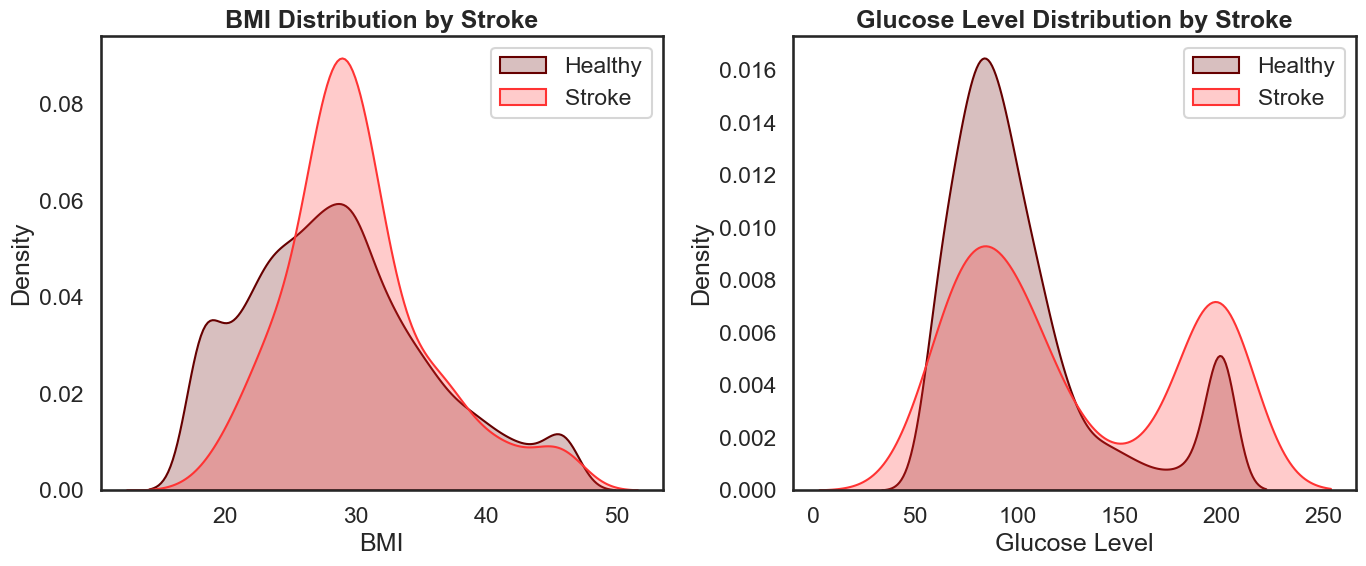

In [173]:
# Using side-by-side KDE plots to compare BMI and glucose distributions for stroke vs non-stroke groups.
# This visualization helps identify whether physiological factors such as body mass and blood glucose 
# show meaningful separation between the two populations, indicating their potential role as stroke risk predictors.

colors = ['#FF9999','#FF6666','#FF3333','#660000','#990000']

sn.set_style("white")
fig, axes = plt.subplots(1, 2, figsize=(14,6))

sn.kdeplot(
    data=df[df['stroke']==0],
    x='bmi',
    label='Healthy',
    fill=True,
    color=colors[3],
    ax=axes[0]
)

sn.kdeplot(
    data=df[df['stroke']==1],
    x='bmi',
    label='Stroke',
    fill=True,
    color=colors[2], 
    ax=axes[0]
)

axes[0].set_title("BMI Distribution by Stroke", fontweight='bold')
axes[0].set_xlabel("BMI")
axes[0].legend()


sn.kdeplot(
    data=df[df['stroke']==0],
    x='avg_glucose_level',
    label='Healthy',
    fill=True,
    color=colors[3],  
    ax=axes[1]
)

sn.kdeplot(
    data=df[df['stroke']==1],
    x='avg_glucose_level',
    label='Stroke',
    fill=True,
    color=colors[2], 
    ax=axes[1]
)

axes[1].set_title("Glucose Level Distribution by Stroke", fontweight='bold')
axes[1].set_xlabel("Glucose Level")
axes[1].legend()

plt.tight_layout()
plt.show()

The graphs compare BMI and glucose levels between healthy individuals and stroke patients. They show that stroke patients generally have higher BMI and more variable — often higher — glucose levels, suggesting that elevated BMI and glucose may be associated with an increased risk of stroke


4.Does smoking significantly increase the risk of stroke?


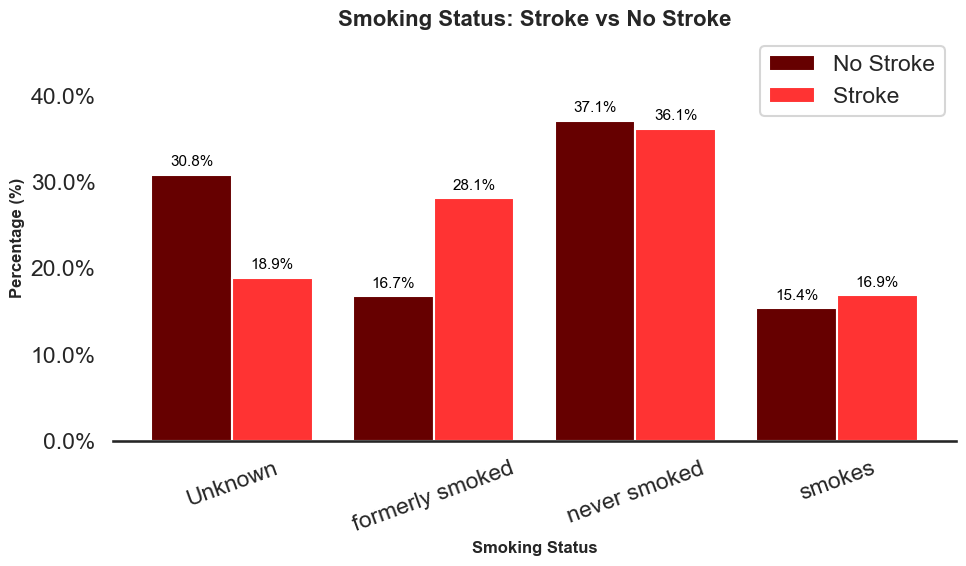

In [174]:
# Creating a grouped bar chart to compare smoking status percentages between stroke and non-stroke groups.
# This visualization helps reveal whether current, former, or never-smoking patterns differ meaningfully 
# between the two populations, highlighting smoking as a potential behavioral risk factor for stroke.


str_only = df[df['stroke'] == 1]
no_str_only = df[df['stroke'] == 0]

positive = str_only["smoking_status"].value_counts(normalize=True) * 100
negative = no_str_only["smoking_status"].value_counts(normalize=True) * 100

all_categories = sorted(set(positive.index).union(set(negative.index)))
positive = positive.reindex(all_categories, fill_value=0)
negative = negative.reindex(all_categories, fill_value=0)

plt.figure(figsize=(10,6))

x = np.arange(len(all_categories))

plt.bar(x - 0.2, negative.values, width=0.4, color="#660000", label="No Stroke")
plt.bar(x + 0.2, positive.values, width=0.4, color="#FF3333", label="Stroke")

# Titles and labels
plt.title("Smoking Status: Stroke vs No Stroke", fontsize=16, fontweight='bold')
plt.xlabel("Smoking Status", fontsize=12, fontweight='bold')
plt.ylabel("Percentage (%)", fontsize=12, fontweight='bold')
plt.xticks(x, all_categories, rotation=20)

for i, v in enumerate(negative.values):
    plt.text(i - 0.2, v + 1, f"{v:.1f}%", ha='center', fontsize=11, color='black')

for i, v in enumerate(positive.values):
    plt.text(i + 0.2, v + 1, f"{v:.1f}%", ha='center', fontsize=11, color='black')

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter())
sn.despine(left=True, right=True)
plt.ylim(0, max(positive.max(), negative.max()) + 10)
plt.legend()
plt.tight_layout()
plt.show()

The graph compares smoking habits between individuals who experienced a stroke and those who did not. It shows a clear pattern: current smokers and former smokers appear more often in the stroke group, while people who never smoked are more common in the non‑stroke group. This suggests that both current and past smoking are associated with a higher likelihood of stroke.


5.Is heart disease a significant risk factor for stroke occurrence?


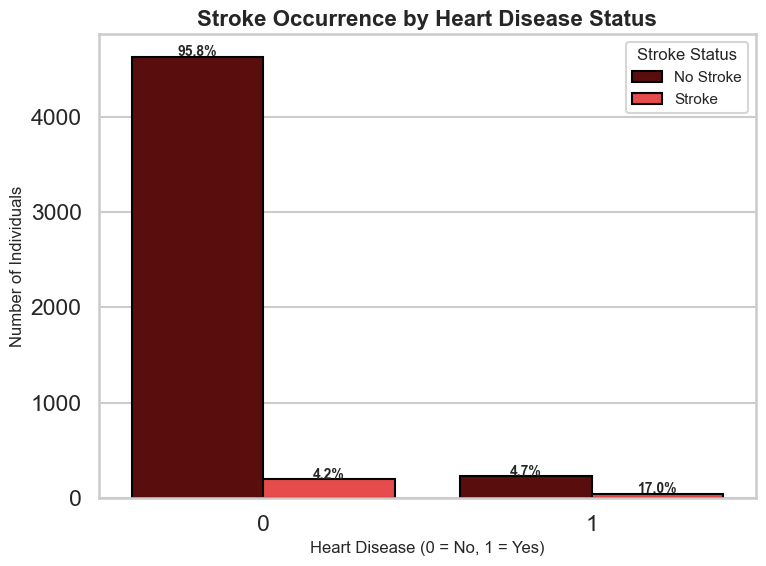

In [175]:
# Using a count plot to compare stroke occurrence between individuals with and without heart disease.
# This visualization helps assess whether pre-existing cardiac conditions are associated with a higher
# proportion of stroke cases, highlighting heart disease as a potential clinical risk factor.

sn.set_style("whitegrid")

plt.figure(figsize=(8,6))

palette = {0: '#660000', 1: '#FF3333'}

sn.countplot(
    data=df,
    x='heart_disease',
    hue='stroke',
    palette=palette,
    edgecolor='black'
)

plt.title("Stroke Occurrence by Heart Disease Status", fontsize=16, fontweight='bold')
plt.xlabel("Heart Disease (0 = No, 1 = Yes)", fontsize=12)
plt.ylabel("Number of Individuals", fontsize=12)

plt.legend(
    title="Stroke Status",
    labels=["No Stroke", "Stroke"],
    fontsize=11,
    title_fontsize=12
)

ax = plt.gca()
total_counts = df['heart_disease'].value_counts()

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        percentage = height / total_counts[int(p.get_x() + p.get_width()/2)] * 100
        ax.text(
            p.get_x() + p.get_width()/2,
            height + 0.5,
            f"{percentage:.1f}%",
            ha='center',
            fontsize=10,
            fontweight='bold'
        )

plt.tight_layout()
plt.show()

The graph compares the number of stroke cases between individuals with and without heart disease. A clear pattern emerges: people with heart disease show a much higher proportion of stroke cases compared to those without heart disease. In contrast, individuals without heart disease are found mostly in the non‑stroke group.


6.Is work type associated with hypertension and stroke risk?


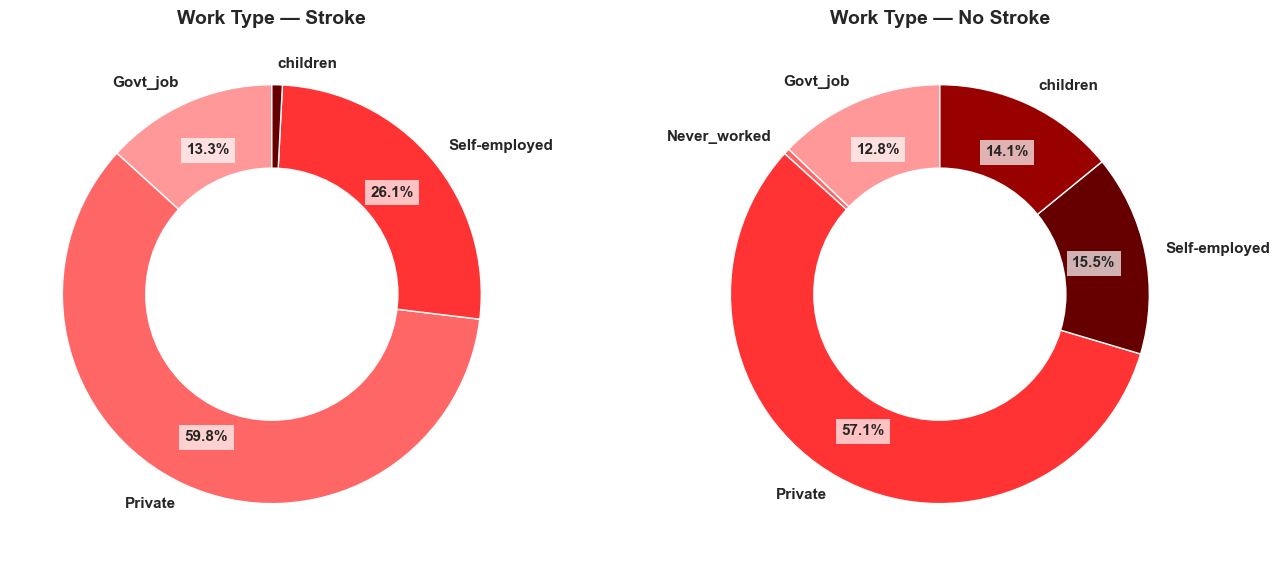

In [176]:
# Using a count plot to compare stroke occurrence between individuals with and without heart disease.
# This visualization helps assess whether pre-existing cardiac conditions are associated with a higher
# proportion of stroke cases, highlighting heart disease as a potential clinical risk factor.

colors = ['#FF9999','#FF6666','#FF3333','#660000','#990000']

stroke_counts = str_only["work_type"].value_counts().sort_index()
no_stroke_counts = no_str_only["work_type"].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14,6))

def autopct_format(pct):
    return f'{pct:.1f}%' if pct > 3 else ''  # מסתיר אחוזים קטנים מאוד

wedges, texts, autotexts = axes[0].pie(
    stroke_counts,
    labels=stroke_counts.index,
    autopct=autopct_format,
    startangle=90,
    colors=colors[:len(stroke_counts)],
    pctdistance=0.75,
    textprops={'fontsize':11, 'fontweight':'bold'},
    wedgeprops={'linewidth': 1, 'edgecolor': 'white'}
)

for t in autotexts:
    t.set_bbox(dict(facecolor='white', alpha=0.7, edgecolor='none'))

centre_circle = plt.Circle((0,0), 0.60, fc='white')
axes[0].add_artist(centre_circle)
axes[0].set_title("Work Type — Stroke", fontsize=14, fontweight='bold')


wedges2, texts2, autotexts2 = axes[1].pie(
    no_stroke_counts,
    labels=no_stroke_counts.index,
    autopct=autopct_format,
    startangle=90,
    colors=colors[:len(no_stroke_counts)],
    pctdistance=0.75,
    textprops={'fontsize':11, 'fontweight':'bold'},
    wedgeprops={'linewidth': 1, 'edgecolor': 'white'}
)

for t in autotexts2:
    t.set_bbox(dict(facecolor='white', alpha=0.7, edgecolor='none'))

centre_circle2 = plt.Circle((0,0), 0.60, fc='white')
axes[1].add_artist(centre_circle2)
axes[1].set_title("Work Type — No Stroke", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

The donut charts compare the distribution of work types between individuals who experienced a stroke and those who did not. Each segment represents the proportion of people within a specific work category. The comparison reveals differences in how work types are distributed across the two groups, suggesting that certain occupations may be associated with varying levels of stroke risk.


7.Does living in an urban versus rural area affect the likelihood of experiencing a stroke?


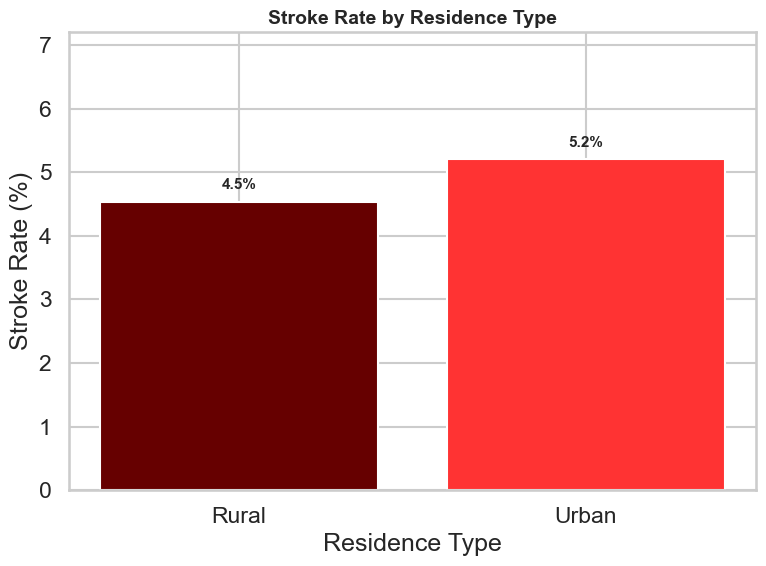

In [177]:
# Plotting the stroke rate by residence type to examine whether living in rural or urban areas 
# is associated with differences in stroke prevalence. This helps identify potential environmental 
# or lifestyle factors linked to stroke risk.

colors = ['#FF9999','#FF6666','#FF3333','#660000','#990000']

residence_stroke = df.groupby('Residence_type')['stroke'].mean() * 100

residence_stroke.index = ['Rural', 'Urban']

plt.figure(figsize=(8,6))

bars = plt.bar(
    residence_stroke.index,
    residence_stroke.values,
    color=[colors[3], colors[2]] )

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.2,
        f"{height:.1f}%",
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.title("Stroke Rate by Residence Type", fontsize=14, fontweight='bold')
plt.xlabel("Residence Type")
plt.ylabel("Stroke Rate (%)")

plt.ylim(0, max(residence_stroke.values) + 2)
plt.tight_layout()
plt.show()

The bar chart shows the stroke rate by residence type (Urban vs. Rural). Each bar represents the percentage of individuals who experienced a stroke within each group, and the values displayed above the bars indicate the exact percentages.

8.Is marital status associated with higher or lower stroke risk?


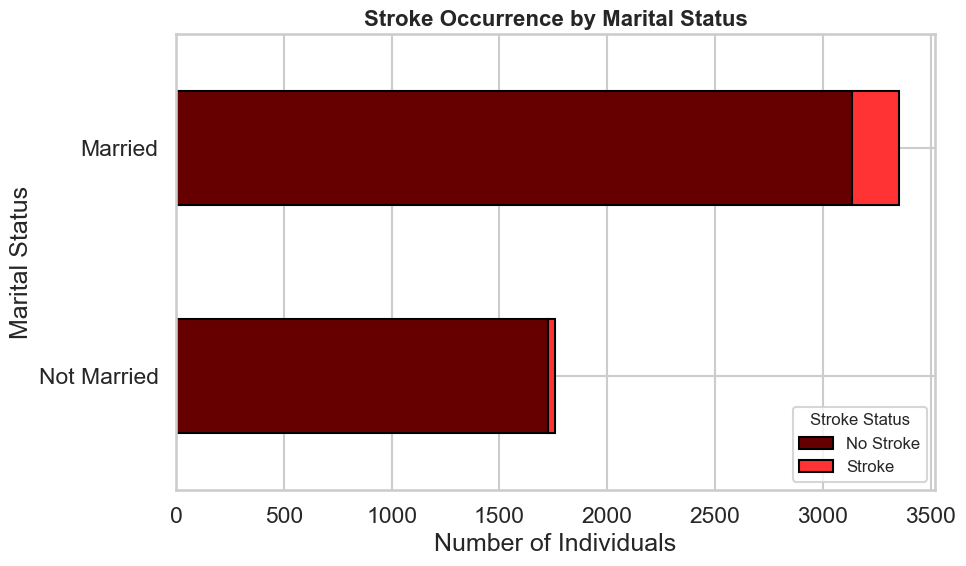

In [178]:
# Using a stacked horizontal bar chart to compare stroke occurrence between married and non-married individuals.
# This visualization helps reveal whether marital status is associated with differences in stroke prevalence,
# potentially indicating social, lifestyle, or support-related factors that influence stroke risk.

plt.style.use('ggplot')  
sn.set_context("talk")
sn.set_style("whitegrid")  

colors = ['#FF9999','#FF6666','#FF3333','#660000','#990000']

stroke_counts = df.groupby('ever_married')['stroke'].value_counts().unstack().fillna(0)
stroke_counts.index = ['Not Married', 'Married']

stroke_counts.plot(
    kind='barh',
    stacked=True,
    color=[colors[3], colors[2]],
    figsize=(10,6),
    edgecolor='black'
)

plt.title("Stroke Occurrence by Marital Status", fontsize=16, fontweight='bold')
plt.xlabel("Number of Individuals")
plt.ylabel("Marital Status")
plt.legend(title="Stroke Status", labels=["No Stroke", "Stroke"], fontsize=12, title_fontsize=12)
plt.tight_layout()
plt.show()

This horizontal stacked bar chart displays the number of individuals with and without a stroke, grouped by marital status. Each bar represents a different marital category, with segments indicating the counts of stroke and non‑stroke cases. This layout makes it easy to compare the groups and visualize how stroke cases are distributed across marital statuses.


9.Can high workload or work-related stress lead to high blood pressure and subsequently increase stroke risk?

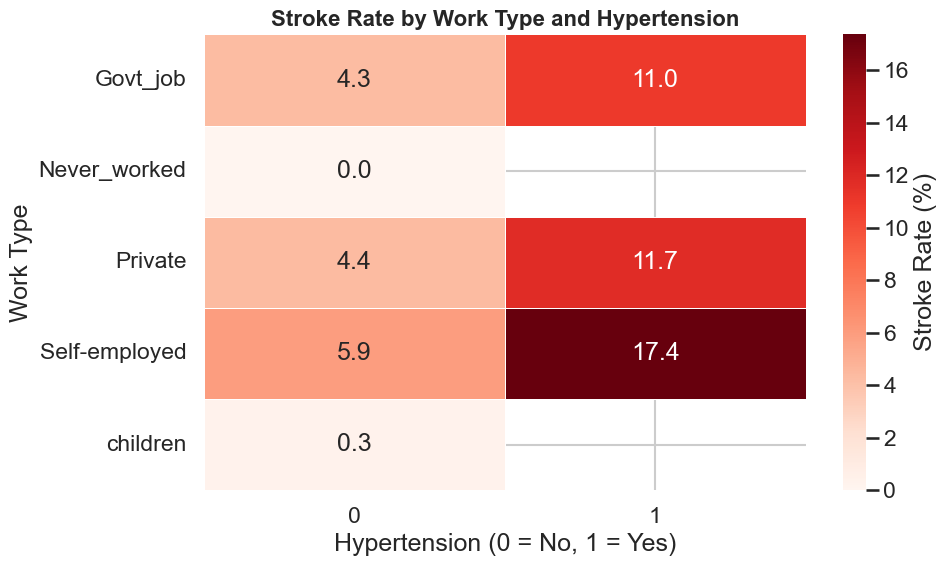

In [179]:
# Creating a heatmap to examine how stroke rates vary across combinations of work type and hypertension status.
# This visualization highlights potential interaction effects, showing whether certain occupations combined 
# with hypertension are associated with higher stroke prevalence.

pivot = df.pivot_table(
    values='stroke',
    index='work_type',
    columns='hypertension',
    aggfunc='mean'
) * 100

plt.figure(figsize=(10,6))

sn.heatmap(
    pivot,
    annot=True,
    fmt=".1f",
    cmap="Reds",
    linewidths=0.5,
    cbar_kws={'label': 'Stroke Rate (%)'}
)

plt.title("Stroke Rate by Work Type and Hypertension", fontsize=16, fontweight='bold')
plt.xlabel("Hypertension (0 = No, 1 = Yes)")
plt.ylabel("Work Type")
plt.tight_layout()
plt.show()

The heatmap shows how stroke rates vary across different work types and hypertension levels. A clear pattern emerges: individuals with hypertension have a significantly higher stroke rate in every work category, with the increase especially noticeable in occupations typically linked to higher workload or stress (such as private or self‑employed jobs).
Conclusion: The graph supports the idea that work‑related stress may contribute to hypertension, which in turn increases the risk of stroke.

10.Which variables serve as the strongest predictors of stroke?


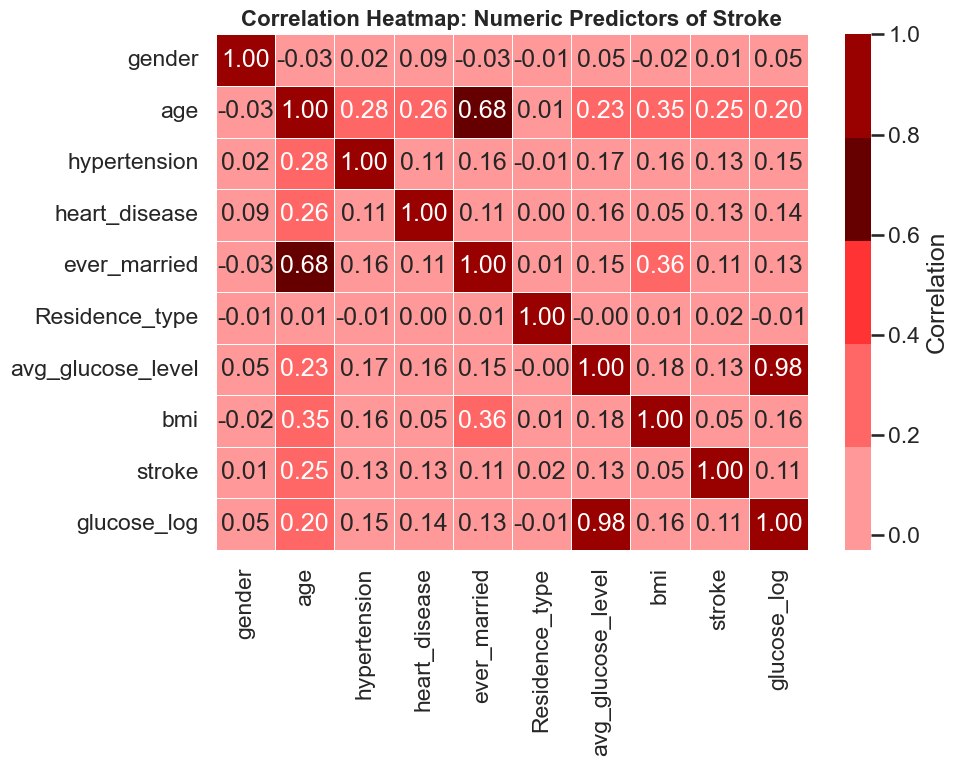

In [180]:
# Generating a correlation heatmap to examine linear relationships between all numeric variables.
# This helps identify which features are most strongly associated with stroke and highlights potential
# multicollinearity issues that may affect model performance.

colors = ['#FF9999','#FF6666','#FF3333','#660000','#990000'] 

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
df_numeric = df[numeric_cols]

corr = df_numeric.corr()

plt.figure(figsize=(10,8))
sn.heatmap(
    corr,
    annot=True,       
    fmt=".2f",
    cmap=sn.color_palette(colors, as_cmap=True),  
    linewidths=0.5,
    cbar_kws={'label': 'Correlation'}
)

plt.title("Correlation Heatmap: Numeric Predictors of Stroke", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

The correlation heatmap shows the strength of relationships between numeric variables in the stroke dataset. The variables with the highest positive correlations with stroke are age, hypertension, heart disease, and average glucose level, suggesting they are the most meaningful predictors of stroke risk. In contrast, variables such as gender, residence type, and BMI show weak correlations with stroke, indicating limited predictive value.

                                    Stroke Analysis: Conclusion and Key Findings


The analysis reveals several strong and consistent patterns across demographic, lifestyle, and clinical variables.
Age, hypertension, heart disease, elevated glucose levels, and smoking status all demonstrate clear associations with increased stroke risk.
Work‑related factors also show meaningful variation, particularly when combined with hypertension, suggesting that occupational stress may indirectly contribute to stroke likelihood.
Overall, the data shows a notable oscillation in variance across several predictors, reflecting the heterogeneous nature of the population and the multifactorial structure of stroke risk.
From a practical perspective, these findings highlight the importance of early screening for high‑risk groups, targeted public‑health interventions, and improved awareness of modifiable lifestyle factors.
Future research may expand this analysis by incorporating predictive modeling, longitudinal data, or additional clinical variables to refine risk estimation and support more personalized prevention strategies.
